# Import example subject behavioral data

This notebook loads behavioral and stimulus-sequence `.mat` files for one example subject from `data/raw/`, ignoring the eyetracking files. It creates:

- `trials_df`: one row per behavioral trial
- `samples_df`: one row per sample within each trial
- `block_metadata_df`: one row per block with values that do not vary trial-to-trial

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio

In [2]:
DATA_ROOT = Path("data/raw")
if not DATA_ROOT.exists():
    DATA_ROOT = Path("~/Documents/academic/data/Murphy2021/raw").expanduser()
EXAMPLE_SUBJECT = "DCB"
INCLUDE_TRAINING = False

subject_dir = DATA_ROOT / EXAMPLE_SUBJECT
subject_dir

WindowsPath('C:/Users/parja/Documents/academic/data/Murphy2021/raw/DCB')

In [3]:
def load_mat(path):
    """Load a MATLAB .mat file and drop scipy's private metadata keys."""
    mat = sio.loadmat(path, squeeze_me=True, struct_as_record=False)
    return {key: value for key, value in mat.items() if not key.startswith("__")}


def matlab_value_to_python(value):
    """Convert MATLAB scalar/array/struct values into notebook-friendly Python objects."""
    if hasattr(value, "_fieldnames"):
        return {field: matlab_value_to_python(getattr(value, field)) for field in value._fieldnames}

    if isinstance(value, np.ndarray):
        if value.ndim == 0:
            return matlab_value_to_python(value.item())
        return value.tolist()

    if isinstance(value, np.generic):
        return value.item()

    return value


def flatten_dict(d, prefix=""):
    """Flatten nested metadata dictionaries into dot-separated columns."""
    rows = {}
    for key, value in d.items():
        name = f"{prefix}.{key}" if prefix else key
        if isinstance(value, dict):
            rows.update(flatten_dict(value, name))
        else:
            rows[name] = value
    return rows


def parse_subject_session_block(path):
    """Read participant/session/block from file names like DCB_1_1.mat."""
    parts = path.stem.split("_")
    block = int(parts[-1])
    session_number = int(parts[-2])
    participant_id = "_".join(parts[:-2])
    return participant_id, session_number, block

In [4]:
session_dirs = sorted(
    path
    for path in subject_dir.iterdir()
    if path.is_dir() and (INCLUDE_TRAINING or path.name != "Training")
)

session_dirs

[WindowsPath('C:/Users/parja/Documents/academic/data/Murphy2021/raw/DCB/S1'),
 WindowsPath('C:/Users/parja/Documents/academic/data/Murphy2021/raw/DCB/S2'),
 WindowsPath('C:/Users/parja/Documents/academic/data/Murphy2021/raw/DCB/S3')]

In [5]:
behav_columns = [
    "correct_response_dist",
    "response",
    "accuracy",
    "rt_from_go_cue",
    "trial_onset_ptb",
    "fixation_break_count",
]

trial_frames = []
sample_frames = []
block_metadata_rows = []

for session_dir in session_dirs:
    behaviour_dir = session_dir / "Behaviour"
    sample_seqs_dir = session_dir / "Sample_seqs"

    for behav_path in sorted(behaviour_dir.glob("*.mat")):
        sample_path = sample_seqs_dir / behav_path.name
        if not sample_path.exists():
            raise FileNotFoundError(f"Missing matching Sample_seqs file for {behav_path}")

        participant_id, session_number, block = parse_subject_session_block(behav_path)
        block_id = f"{participant_id}_S{session_number}_B{block}"

        behav_mat = load_mat(behav_path)
        sample_mat = load_mat(sample_path)

        behav = np.asarray(behav_mat["Behav"])
        t_refresh = np.asarray(behav_mat["tRefresh"])
        stim_in = np.asarray(sample_mat["stimIn"])
        distseqs = np.asarray(sample_mat["distseqs"])
        pswitch = np.asarray(sample_mat["pswitch"])

        if behav.ndim != 2 or behav.shape[1] != len(behav_columns):
            raise ValueError(f"Unexpected Behav shape in {behav_path}: {behav.shape}")

        n_planned_trials, n_samples = stim_in.shape
        n_trials = behav.shape[0]
        if n_trials > n_planned_trials:
            raise ValueError(
                f"More behavioral trials than stimulus rows for {block_id}: "
                f"Behav has {n_trials}, stimIn has {n_planned_trials}"
            )

        # Some blocks can be interrupted. Keep only rows with completed behavior
        # in the trial- and sample-level dataframes, and record the mismatch below.
        stim_in_completed = stim_in[:n_trials]
        distseqs_completed = distseqs[:n_trials]
        pswitch_completed = pswitch[:n_trials]
        t_refresh_completed = t_refresh[:n_trials]

        trial_df = pd.DataFrame(behav, columns=behav_columns)
        trial_df.insert(0, "trial", np.arange(1, n_trials + 1))
        trial_df.insert(0, "block", block)
        trial_df.insert(0, "session", session_number)
        trial_df.insert(0, "session_label", session_dir.name)
        trial_df.insert(0, "participant_id", participant_id)
        trial_df.insert(0, "subject_folder", subject_dir.name)
        trial_df.insert(0, "block_id", block_id)

        trial_df["n_presented_samples"] = np.sum(~np.isnan(stim_in_completed), axis=1)
        trial_df["final_sample_location"] = stim_in_completed[
            np.arange(n_trials), trial_df["n_presented_samples"].to_numpy() - 1
        ]
        trial_frames.append(trial_df)

        sample_df = pd.DataFrame(
            {
                "block_id": np.repeat(block_id, n_trials * n_samples),
                "subject_folder": np.repeat(subject_dir.name, n_trials * n_samples),
                "participant_id": np.repeat(participant_id, n_trials * n_samples),
                "session_label": np.repeat(session_dir.name, n_trials * n_samples),
                "session": np.repeat(session_number, n_trials * n_samples),
                "block": np.repeat(block, n_trials * n_samples),
                "trial": np.repeat(np.arange(1, n_trials + 1), n_samples),
                "sample": np.tile(np.arange(1, n_samples + 1), n_trials),
                "stim_location_deg": stim_in_completed.reshape(-1),
                "generative_dist": distseqs_completed.reshape(-1),
                "distribution_switch": pswitch_completed.reshape(-1),
                "sample_onset_from_trial_s": t_refresh_completed.reshape(-1),
            }
        )
        sample_frames.append(sample_df)

        metadata = {
            "block_id": block_id,
            "subject_folder": subject_dir.name,
            "participant_id": participant_id,
            "session_label": session_dir.name,
            "session": session_number,
            "block": block,
            "n_completed_trials": n_trials,
            "n_planned_trials": n_planned_trials,
            "has_incomplete_behaviour": n_trials != n_planned_trials,
            "n_samples": n_samples,
            "behaviour_file": str(behav_path),
            "sample_seqs_file": str(sample_path),
            "pshort": matlab_value_to_python(sample_mat["pshort"]),
        }
        for struct_name in ["gen", "timing", "stim"]:
            metadata.update(
                flatten_dict({struct_name: matlab_value_to_python(sample_mat[struct_name])})
            )
        block_metadata_rows.append(metadata)

trials_df = pd.concat(trial_frames, ignore_index=True)
samples_df = pd.concat(sample_frames, ignore_index=True)
block_metadata_df = pd.DataFrame(block_metadata_rows)

trials_df.shape, samples_df.shape, block_metadata_df.shape

((2005, 15), (24060, 12), (27, 58))

In [6]:
trials_df.head()

,block_id,subject_folder,participant_id,session_label,session,block,trial,correct_response_dist,response,accuracy,rt_from_go_cue,trial_onset_ptb,fixation_break_count,n_presented_samples,final_sample_location
0,DCB_S1_B1,DCB,DCB,S1,1,1,1,1.0,1.0,1.0,1.515773,1.497944e+09,0.0,8,19.0
1,DCB_S1_B1,DCB,DCB,S1,1,1,2,2.0,2.0,1.0,0.007256,1.497944e+09,0.0,12,4.0
2,DCB_S1_B1,DCB,DCB,S1,1,1,3,2.0,1.0,0.0,0.006124,1.497944e+09,0.0,12,11.0
3,DCB_S1_B1,DCB,DCB,S1,1,1,4,1.0,1.0,1.0,0.006226,1.497944e+09,0.0,12,29.0
4,DCB_S1_B1,DCB,DCB,S1,1,1,5,1.0,1.0,1.0,0.006103,1.497944e+09,0.0,4,47.0


In [7]:
samples_df.head(15)

,block_id,subject_folder,participant_id,session_label,session,block,trial,sample,stim_location_deg,generative_dist,distribution_switch,sample_onset_from_trial_s
0,DCB_S1_B1,DCB,DCB,S1,1,1,1,1,61.0,1.0,0.0,0.399993
1,DCB_S1_B1,DCB,DCB,S1,1,1,1,2,-38.0,1.0,0.0,0.799975
2,DCB_S1_B1,DCB,DCB,S1,1,1,1,3,81.0,1.0,0.0,1.199959
3,DCB_S1_B1,DCB,DCB,S1,1,1,1,4,7.0,1.0,0.0,1.599944
4,DCB_S1_B1,DCB,DCB,S1,1,1,1,5,-37.0,1.0,0.0,1.999933
5,DCB_S1_B1,DCB,DCB,S1,1,1,1,6,28.0,1.0,0.0,2.399927
6,DCB_S1_B1,DCB,DCB,S1,1,1,1,7,20.0,1.0,0.0,2.799911
7,DCB_S1_B1,DCB,DCB,S1,1,1,1,8,19.0,1.0,0.0,3.199891
8,DCB_S1_B1,DCB,DCB,S1,1,1,1,9,NaN,NaN,NaN,0.000000
9,DCB_S1_B1,DCB,DCB,S1,1,1,1,10,NaN,NaN,NaN,0.000000


In [8]:
block_metadata_df.head()

,block_id,subject_folder,participant_id,session_label,session,block,n_completed_trials,n_planned_trials,has_incomplete_behaviour,n_samples,...,stim.audio.device.NrOutputChannels,stim.audio.device.LowInputLatency,stim.audio.device.HighInputLatency,stim.audio.device.LowOutputLatency,stim.audio.device.HighOutputLatency,stim.audio.device.DefaultSampleRate,stim.audio.h,stim.audio.tonebuf,stim.audio.tonepos,stim.cbartex
0,DCB_S1_B1,DCB,DCB,S1,1,1,76,76,False,12,...,128,0.01161,0.04644,0.01161,0.04644,44100,0,"[[0.0, 0.00044548156986781365, 0.0009088281626...","[[0, 5512], [5513, 11025], [11026, 22051]]",13
1,DCB_S1_B2,DCB,DCB,S1,1,2,76,76,False,12,...,128,0.01161,0.04644,0.01161,0.04644,44100,0,"[[0.0, 0.00044548156986781365, 0.0009088281626...","[[0, 5512], [5513, 11025], [11026, 22051]]",13
2,DCB_S1_B3,DCB,DCB,S1,1,3,76,76,False,12,...,128,0.01161,0.04644,0.01161,0.04644,44100,0,"[[0.0, 0.00044548156986781365, 0.0009088281626...","[[0, 5512], [5513, 11025], [11026, 22051]]",13
3,DCB_S1_B4,DCB,DCB,S1,1,4,76,76,False,12,...,128,0.01161,0.04644,0.01161,0.04644,44100,0,"[[0.0, 0.00044548156986781365, 0.0009088281626...","[[0, 5512], [5513, 11025], [11026, 22051]]",13
4,DCB_S1_B5,DCB,DCB,S1,1,5,76,76,False,12,...,128,0.01161,0.04644,0.01161,0.04644,44100,0,"[[0.0, 0.00044548156986781365, 0.0009088281626...","[[0, 5512], [5513, 11025], [11026, 22051]]",13


In [9]:
trials_df.groupby(["session_label", "block"]).agg(
    n_trials=("trial", "size"),
    accuracy=("accuracy", "mean"),
    median_rt=("rt_from_go_cue", "median"),
    mean_presented_samples=("n_presented_samples", "mean"),
)

n_trials  accuracy  median_rt  mean_presented_samples
session_label block                                                       
S1            1            76  0.736842   0.006155               10.592105
              2            76  0.776316   0.006148               10.697368
              3            76  0.789474   0.006147               10.789474
              4            76  0.789474   0.006133               10.789474
              5            76  0.789474   0.006121               10.486842
              6            76  0.723684   0.006130               10.855263
              7            76  0.750000   0.006108               10.605263
              8            76  0.815789   0.006128               10.513158
              9            29  0.620690   0.006115               10.551724
S2            1            76  0.697368   0.006124               10.657895
              2            76  0.736842   0.006110               10.565789
              3            76  0.868421   0.006110               10.789474
              4            76  0.750000   0.006109               10.342105
              5            76  0.842105   0.006101               10.855263
              6            76  0.802632   0.006169               10.513158
              7            76  0.842105   0.006156               10.618421
              8            76  0.763158   0.006162               10.802632
              9            76  0.802632   0.006139               10.578947
S3            1            76  0.789474   0.006131               10.355263
              2            76  0.736842   0.006137               10.644737
              3            76  0.802632   0.006135               10.855263
              4            76  0.776316   0.006116               10.802632
              5            76  0.894737   0.006128               10.447368
              6            76  0.763158   0.006121               10.894737
              7            76  0.855263   0.006111               10.578947
              8            76  0.671053   0.006117               10.671053
              9            76  0.828947   0.006103               10.578947

In [10]:
block_metadata_df['n_completed_trials'].sum(), block_metadata_df['n_planned_trials'].sum()

(2005, 2052)

<AxesSubplot: >

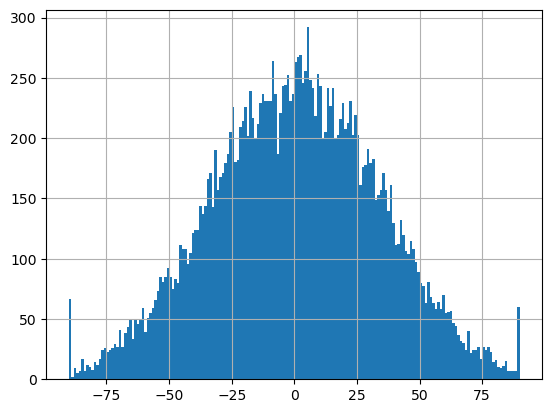

In [15]:
samples_df['stim_location_deg'].hist(bins=np.arange(-90, 91, 1))

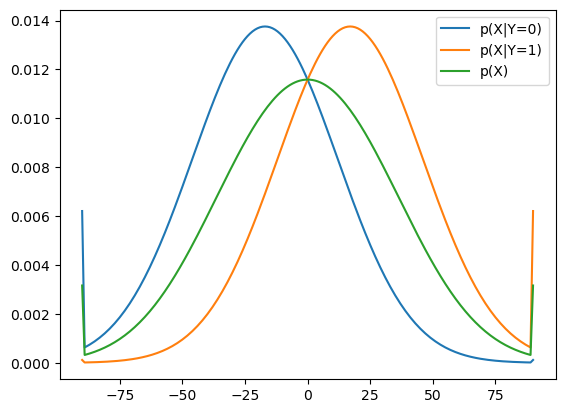

In [26]:
from scipy.stats import norm
from torch import var

mean0, mean1 = -17, 17
std = 29

X = np.arange(-90, 91)
p_XgY0 = np.zeros(181)
p_XgY1 = np.zeros(181)

p_XgY0[0] = norm.cdf(-90.5,loc=mean0,scale=std)
p_XgY1[0] = norm.cdf(-90.5,loc=mean1,scale=std)

p_XgY0[-1] = 1 - norm.cdf(90.5,loc=mean0,scale=std)
p_XgY1[-1] = 1 - norm.cdf(90.5,loc=mean1,scale=std)
for i in range(181):
    p_XgY0[i] += norm.cdf(X[i]+0.5,loc=mean0,scale=std) - norm.cdf(X[i]-0.5,loc=mean0,scale=std)
    p_XgY1[i] += norm.cdf(X[i]+0.5,loc=mean1,scale=std) - norm.cdf(X[i]-0.5,loc=mean1,scale=std)

p_X = 0.5 * p_XgY0 + 0.5 * p_XgY1

import matplotlib.pyplot as plt
plt.plot(X, p_XgY0, label="p(X|Y=0)")
plt.plot(X, p_XgY1, label="p(X|Y=1)")
plt.plot(X, p_X, label="p(X)")
plt.legend()
plt.show()

In [28]:
np.sum(samples_df['stim_location_deg'] == 0)

263

In [21]:
2**9

512

In [20]:
4**5

1024